In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns

FILE_PATH = "../data/final_glacier_ml_dataset.parquet"
df = pd.read_parquet(FILE_PATH)


In [2]:
print("--- Dataset Overview ---")
print(f"Total Rows (Individual Observations): {len(df)}")
print(f"Columns Available: {df.columns.tolist()}")

--- Dataset Overview ---
Total Rows (Individual Observations): 4868
Columns Available: ['id', 'observation_start', 'observation_end', 'mass_balance_annual', 'coordx', 'coordy', 'sgi-id', 'satellite', 'obs_id', 'B11', 'B12', 'B2', 'B3', 'B4', 'B8', 'NDSI', 'area_m2', 'aspect_mean', 'date', 'elev_mean', 'sla', 'slope_mean', 'snow_fraction']


In [3]:
print("\n--- Missing Value Check ---")
print(df[['area_m2', 'sla', 'B2', 'NDSI', 'elev_mean']].isnull().sum())


--- Missing Value Check ---
area_m2        0
sla          421
B2           352
NDSI         353
elev_mean      0
dtype: int64


In [11]:
obs_per_satellite = df["satellite"].value_counts().sort_index()

print(obs_per_satellite)

satellite
landsat5      945
landsat8      430
sentinel2    3493
Name: count, dtype: int64


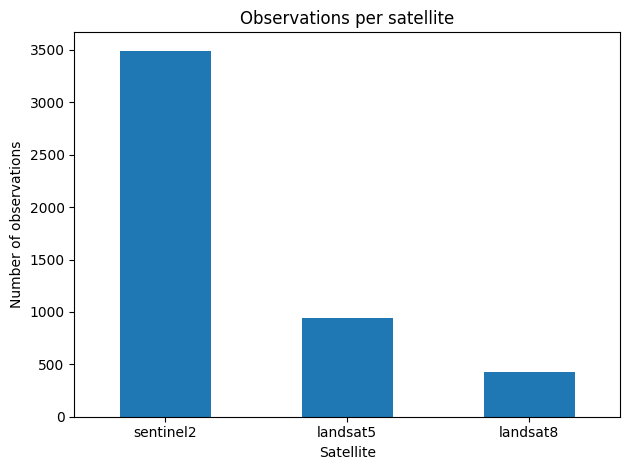

In [12]:
order = ["sentinel2", "landsat5", "landsat8"]
obs_per_satellite = df["satellite"].value_counts().reindex(order, fill_value=0)

obs_per_satellite.plot(kind="bar")
plt.ylabel("Number of observations")
plt.xlabel("Satellite")
plt.title("Observations per satellite")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

observation_start
1983     23
1984     46
1985     22
1986     38
1987     39
1988     39
1989     55
1990     36
1991     45
1992     46
1993     21
1994      1
1995     48
1996     49
1997     32
1998     22
1999     19
2000     18
2002     39
2003     15
2004     13
2005     24
2006     32
2007     24
2008     62
2009     68
2010     69
2012    104
2013     93
2014     87
2015    146
2016    180
2017    551
2018    392
2019    407
2020    416
2021    384
2022    327
2023    310
2024    526
dtype: int64


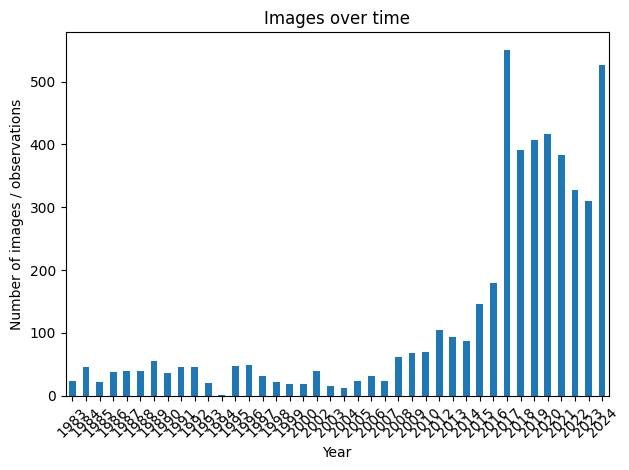

In [14]:
images_per_year = df.groupby(df["observation_start"].dt.year).size()

print(images_per_year)

images_per_year.plot(kind="bar")
plt.ylabel("Number of images / observations")
plt.xlabel("Year")
plt.title("Images over time")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [18]:
obs_per_glacier = df.groupby("sgi-id").size().sort_values(ascending=False)

print(df["sgi-id"].unique())
print(obs_per_glacier)

<ArrowStringArray>
['A10g-05', 'A10g-18', 'A14g-16', 'A14p-01', 'A14p-03', 'A50d-01', 'A50i-06',
 'A50i-07', 'A50i-19', 'A51e-08', 'A51e-12', 'A51e-37', 'A54g-03', 'A55f-03',
  'B16-01',  'B22-01',  'B36-26',  'B43-03',  'B45-04',  'B52-20',  'B52-24',
  'B52-29',  'B52-32',  'B52-33',  'B53-14',  'B55-15',  'B56-03',  'B56-14',
  'B73-13',  'B75-12',  'B82-14',  'B82-27',  'B83-03',  'B85-23',  'B93-06',
  'C14-10',  'E23-16',  'E23-18']
Length: 38, dtype: str
sgi-id
B56-03     516
B52-32     333
B52-29     333
B52-24     333
A50i-19    239
B56-14     231
B36-26     211
B45-04     203
A10g-05    195
C14-10     175
B82-27     171
B82-14     165
B43-03     148
B83-03     140
A54g-03    122
B55-15     111
B93-06     108
A14g-16    105
B53-14     101
A51e-12    100
A51e-08     79
B22-01      75
B16-01      72
E23-16      69
E23-18      68
A55f-03     64
A10g-18     62
B73-13      59
B75-12      58
A50d-01     46
B52-20      43
B85-23      41
B52-33      38
A51e-37     21
A14p-01     16
A1

satellite  landsat5  landsat8  sentinel2
sgi-id                                  
A10g-05         125        17         53
A10g-18          27        17         18
A14g-16           0         0        105
A14p-01           0        16          0
A14p-03           0         7          0
A50d-01           9         7         30
A50i-06           5         0          0
A50i-07           5         0          0
A50i-19         112        21        106
A51e-08           0        22         57
A51e-12           0        22         78
A51e-37           0        16          5
A54g-03           0        16        106
A55f-03           2         8         54
B16-01            0        18         54
B22-01            3        18         54
B36-26           83        22        106
B43-03           20        22        106
B45-04           81        17        105
B52-20           43         0          0
B52-24           81        17        235
B52-29           81        17        235
B52-32          

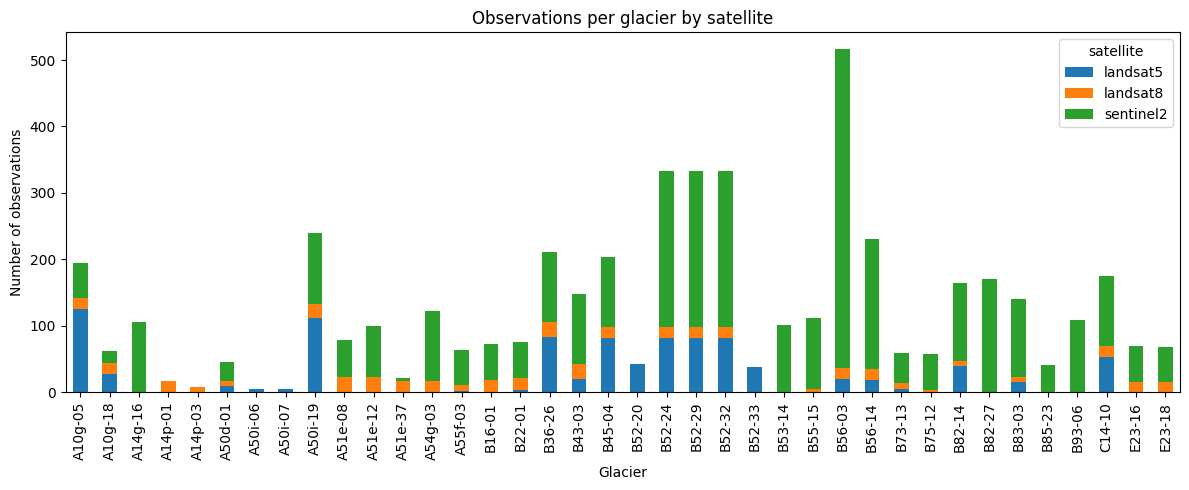

In [19]:
obs_per_glacier_sat = (
    df.groupby(["sgi-id", "satellite"])
      .size()
      .unstack(fill_value=0)
)

print(obs_per_glacier_sat)

obs_per_glacier_sat.plot(kind="bar", stacked=True, figsize=(12,5))
plt.ylabel("Number of observations")
plt.xlabel("Glacier")
plt.title("Observations per glacier by satellite")
plt.tight_layout()
plt.show()

In [20]:
print("Total observations:", len(df))
print("\nObservations per satellite:")
print(df["satellite"].value_counts())

print("\nObservations per glacier:")
print(df["sgi-id"].value_counts())

print("\nDate range:")
print(df["date"].min(), "to", df["date"].max())

Total observations: 4868

Observations per satellite:
satellite
sentinel2    3493
landsat5      945
landsat8      430
Name: count, dtype: int64

Observations per glacier:
sgi-id
B56-03     516
B52-24     333
B52-29     333
B52-32     333
A50i-19    239
B56-14     231
B36-26     211
B45-04     203
A10g-05    195
C14-10     175
B82-27     171
B82-14     165
B43-03     148
B83-03     140
A54g-03    122
B55-15     111
B93-06     108
A14g-16    105
B53-14     101
A51e-12    100
A51e-08     79
B22-01      75
B16-01      72
E23-16      69
E23-18      68
A55f-03     64
A10g-18     62
B73-13      59
B75-12      58
A50d-01     46
B52-20      43
B85-23      41
B52-33      38
A51e-37     21
A14p-01     16
A14p-03      7
A50i-06      5
A50i-07      5
Name: count, dtype: int64

Date range:
1984-08-221 to 2025-09-263


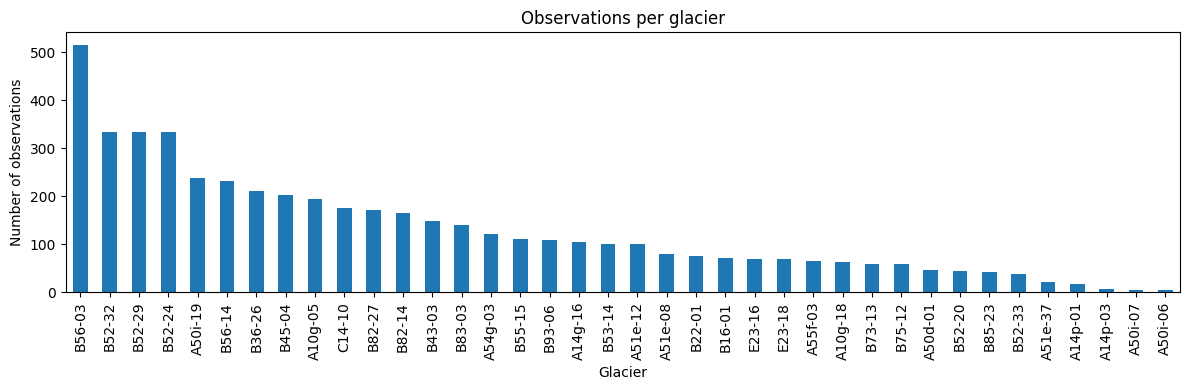

In [16]:
obs_per_glacier.plot(kind="bar", figsize=(12,4))
plt.ylabel("Number of observations")
plt.xlabel("Glacier")
plt.title("Observations per glacier")
plt.tight_layout()
plt.show()

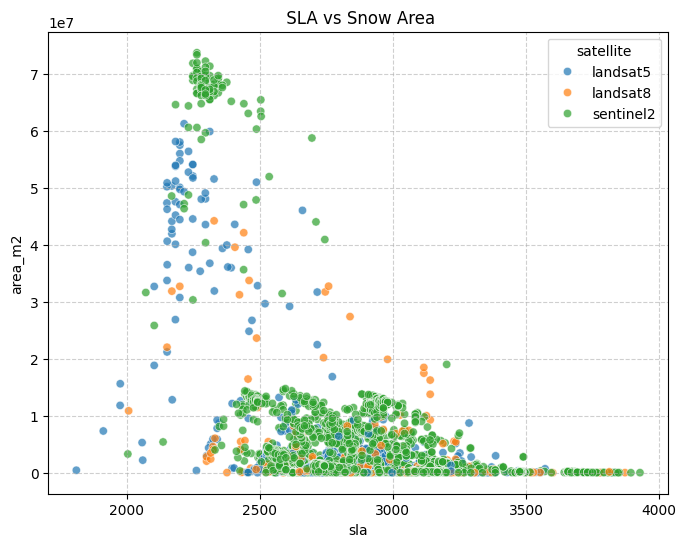

In [10]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='sla', y='area_m2', hue='satellite', alpha=0.7)
plt.title(" SLA vs Snow Area")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


In [21]:
df.head(50)

,id,observation_start,observation_end,mass_balance_annual,coordx,coordy,sgi-id,satellite,obs_id,B11,...,B4,B8,NDSI,area_m2,aspect_mean,date,elev_mean,sla,slope_mean,snow_fraction
0,A10g-05,1983-10-01,1984-09-30,848,2801722,1192164,A10g-05,landsat5,A10g-05_1983-10-01_1984-09-30,NaN,...,NaN,NaN,NaN,0.000000e+00,115.0,1984-09-255,2780.637857,NaN,1.0,NaN
1,A10g-05,1983-10-01,1984-09-30,848,2801722,1192164,A10g-05,landsat5,A10g-05_1983-10-01_1984-09-30,0.016573,...,0.457403,0.440138,0.923351,1.305797e+06,115.0,1984-09-246,2780.637857,2534.149414,1.0,0.999613
2,A10g-05,1984-10-01,1985-09-30,356,2801722,1192164,A10g-05,landsat5,A10g-05_1984-10-01_1985-09-30,0.018328,...,0.762367,0.648472,0.953703,2.083806e+06,115.0,1985-08-225,2780.637857,2541.664679,1.0,0.999939
3,A10g-05,1984-10-01,1985-09-30,356,2801722,1192164,A10g-05,landsat5,A10g-05_1984-10-01_1985-09-30,0.091941,...,0.834892,0.760513,0.803451,2.386846e+06,115.0,1985-08-241,2780.637857,2537.842929,1.0,1.000000
4,A10g-05,1984-10-01,1985-09-30,356,2801722,1192164,A10g-05,landsat5,A10g-05_1984-10-01_1985-09-30,0.063452,...,0.639363,0.613572,0.813637,1.260801e+04,115.0,1985-09-257,2780.637857,2743.084717,1.0,1.000000
5,A10g-05,1984-10-01,1985-09-30,356,2801722,1192164,A10g-05,landsat5,A10g-05_1984-10-01_1985-09-30,0.015432,...,0.794404,0.673064,0.961058,9.631647e+05,115.0,1985-08-225,2780.637857,2513.813582,1.0,1.000000
6,A10g-05,1984-10-01,1985-09-30,356,2801722,1192164,A10g-05,landsat5,A10g-05_1984-10-01_1985-09-30,0.038884,...,0.602531,0.568884,0.872879,7.709278e+05,115.0,1985-08-232,2780.637857,2594.279436,1.0,1.000000
7,A10g-05,1985-10-01,1986-09-30,-166,2801722,1192164,A10g-05,landsat5,A10g-05_1985-10-01_1986-09-30,0.048308,...,0.800248,0.690794,0.881655,1.736180e+06,115.0,1986-09-244,2780.637857,2578.142999,1.0,0.995454
8,A10g-05,1985-10-01,1986-09-30,-166,2801722,1192164,A10g-05,landsat5,A10g-05_1985-10-01_1986-09-30,0.014621,...,0.409861,0.394167,0.921066,1.946713e+06,115.0,1986-08-228,2780.637857,2561.917537,1.0,0.994853
9,A10g-05,1985-10-01,1986-09-30,-166,2801722,1192164,A10g-05,landsat5,A10g-05_1985-10-01_1986-09-30,0.048659,...,0.821441,0.706418,0.882513,1.866009e+06,115.0,1986-09-244,2780.637857,2557.931730,1.0,1.000000


In [7]:
import geemap
import pandas as pd
import ee

rasters = pd.read_pickle("../data/raster_verification.pkl")
df_rasters = pd.DataFrame(rasters)

def inspect_observation(obs_id):
    
    row = df_rasters[df_rasters['obs_id'] == obs_id]
    
    if row.empty:
        print(f"Observation {obs_id} not found in the pickle file.")
        return

    
    mask_img = row.iloc[0]['mask_image']
    
    print(f"Inspecting Observation: {obs_id}")
    
    Map = geemap.Map()
    Map.centerObject(mask_img, 14)
    
    Map.add_basemap('SATELLITE')

    mask_vis = {'min': 0, 'max': 1, 'palette': ['black', 'white'], 'opacity': 0.6}
    Map.addLayer(mask_img, mask_vis, 'Snow Mask (Median)')
    
    return Map


inspect_observation("A10g-05_1985-10-01_1986-09-30")

Inspecting Observation: A10g-05_1985-10-01_1986-09-30


TypeError: 'NoneType' object is not subscriptable

In [ ]:
import ee
import geemap
import pandas as pd

ee.Initialize(project="project-8e6c1255-803c-4395-88f")

df_rasters = pd.read_pickle("../data/raster_verification.pkl")

def show_mask_from_pickle(obs_id, lon=8.4, lat=46.8, zoom=11):
    row = df_rasters[df_rasters["obs_id"] == obs_id]
    if row.empty:
        print(f"{obs_id} not found.")
        return

    mask_img = row.iloc[0]["mask_image"]

    m = geemap.Map()
    m.setCenter(lon, lat, zoom)  

    m.add_basemap("SATELLITE")

    try:
        m.addLayer(
            ee.Image(mask_img).selfMask(),
            {"palette": ["white"], "opacity": 0.7},
            f"Mask {obs_id}"
        )
        return m
    except Exception as e:
        print(f"Could not display mask image: {e}")
        print("The pickled ee.Image is not reusable enough for map display.")

In [ ]:
df_rasters.columns

RangeIndex(start=0, stop=0, step=1)

In [ ]:
import pickle
with open("../data/raster_verification.pkl", "rb") as f:
    data = pickle.load(f)

print(data.dtypes)

obs_id           str
mask_image    object
dtype: object


KeyError: 0